# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('sample_data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [2]:
avg_count_by_month = df['count'].resample('ME').mean().round(0)
avg_count_by_month

,count
datetime,
2011-01-31,55.0
2011-02-28,74.0
2011-03-31,87.0
2011-04-30,111.0
2011-05-31,175.0
2011-06-30,197.0
2011-07-31,204.0
2011-08-31,183.0
2011-09-30,175.0


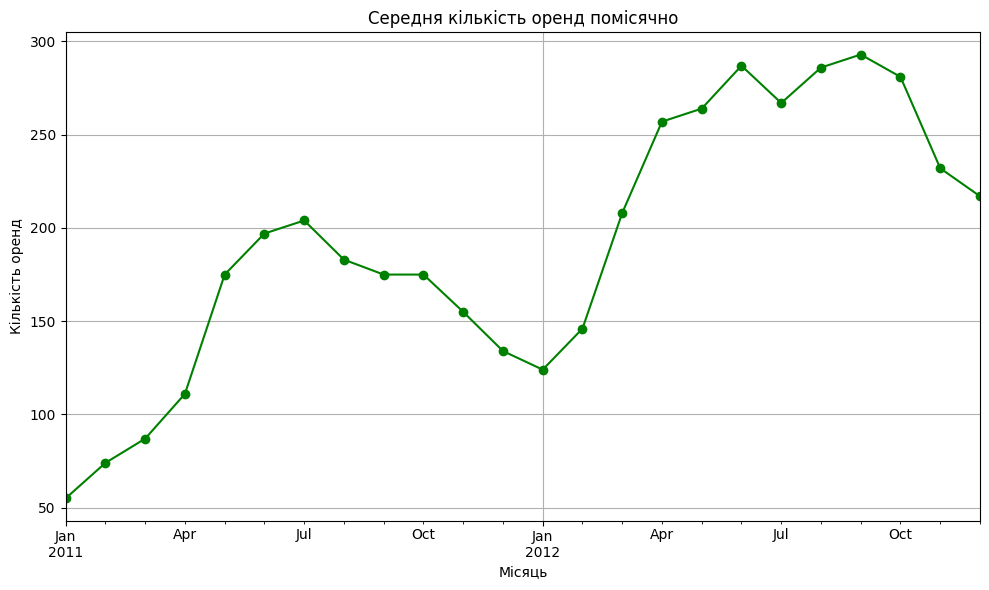

In [3]:
avg_count_by_month.plot(
    figsize = (10,6),
    title = 'Cередня кількість оренд помісячно',
    marker = 'o',
    grid = True,
    color = 'green',
    xlabel = 'Місяць',
    ylabel = 'Кількість оренд'
)

plt.tight_layout()

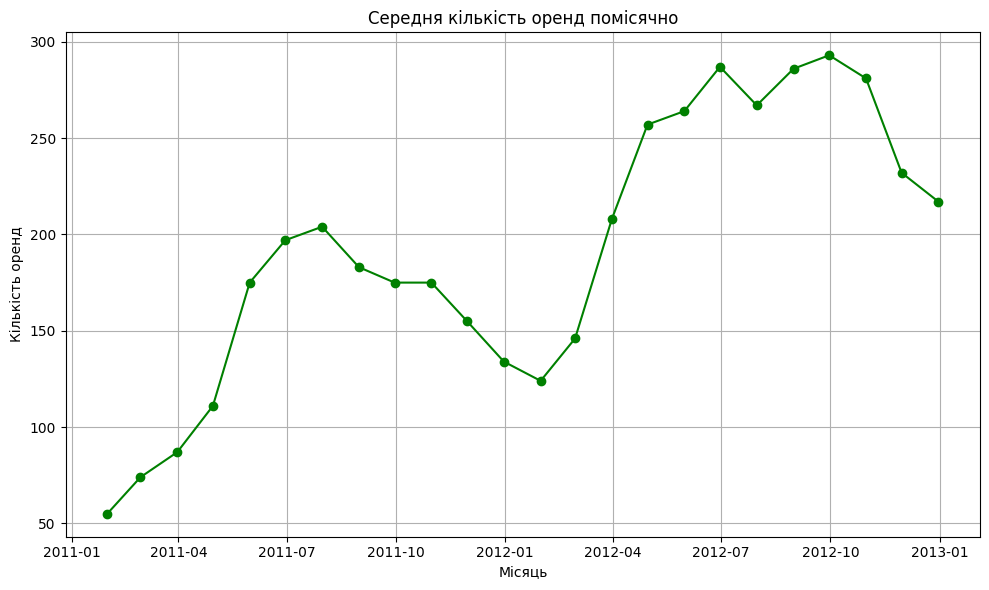

In [4]:
plt.figure(figsize=(10,6))
plt.plot(avg_count_by_month, 'o-', color = 'green')
plt.title('Cередня кількість оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.grid (True)
plt.tight_layout();

**Відповідь:**
Побудова графіків в цих методах відрязняється тим, як задаються умови для виклику функцій для налаштувань графіка.

Pandas (DataFrame.plot()) сам визначає формат осі Х з datetime-індексу, оскільки має власний внутрішній конвертер дат, який відрізняється від Matplotlib. Останній в свою чергу відображає вісь Х за замовчуванням(як в датасеті)

Мені особисто більше подобається Pandas (DataFrame.plot()), як на мене він швидший і легше не загубитись в синтаксисі, а також компактніший.




## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніші?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [5]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

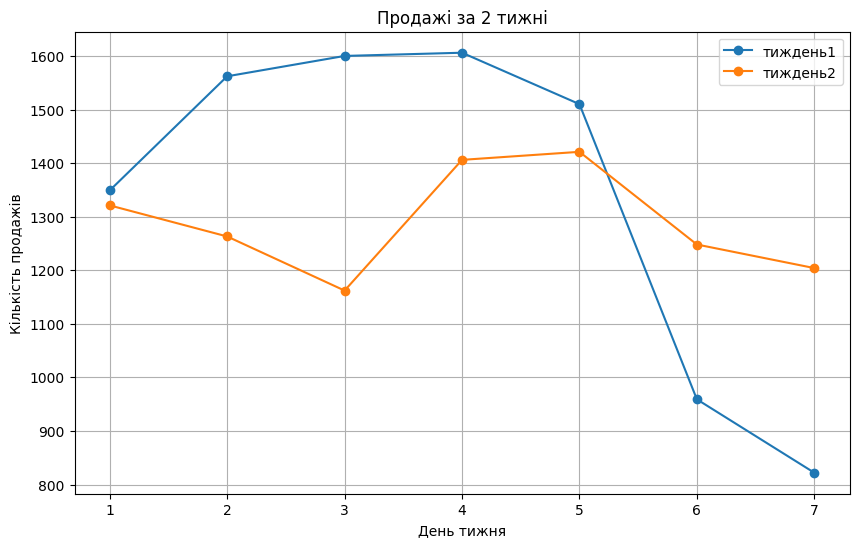

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(days, sales_week1, 'o-', label='тиждень1')
plt.plot(days, sales_week2, 'o-', label='тиждень2')

plt.title('Продажі за 2 тижні')
plt.xlabel('День тижня')
plt.xticks(range(1,8))
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()

**Відповідь:**
1.Аналізуючи графік ми бачимо, що продажі були стабільніші на 2-му тижні.
2.Для того, щоб підкріпити цей висновок за допомогою обчислень, необхідно розрахувати стандартне відхилення.

In [7]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print(
    f'Тиждень1: Стандартне відхилення = {std_week1}', "\n"
    f'Тиждень2: Стандартне відхилення = {std_week2}'
)


Тиждень1: Стандартне відхилення = 299.99857142517004 
Тиждень2: Стандартне відхилення = 90.9060964256355


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [8]:
avg_temp_month = df.groupby('month')['temp'].mean().round(2)
avg_temp_month

avg_count_q = df.groupby('season')['count'].mean().round(0)
avg_count_q

#для 3го humidity_data = df['humidity']



,count
season,
1,116.0
2,215.0
3,234.0
4,199.0


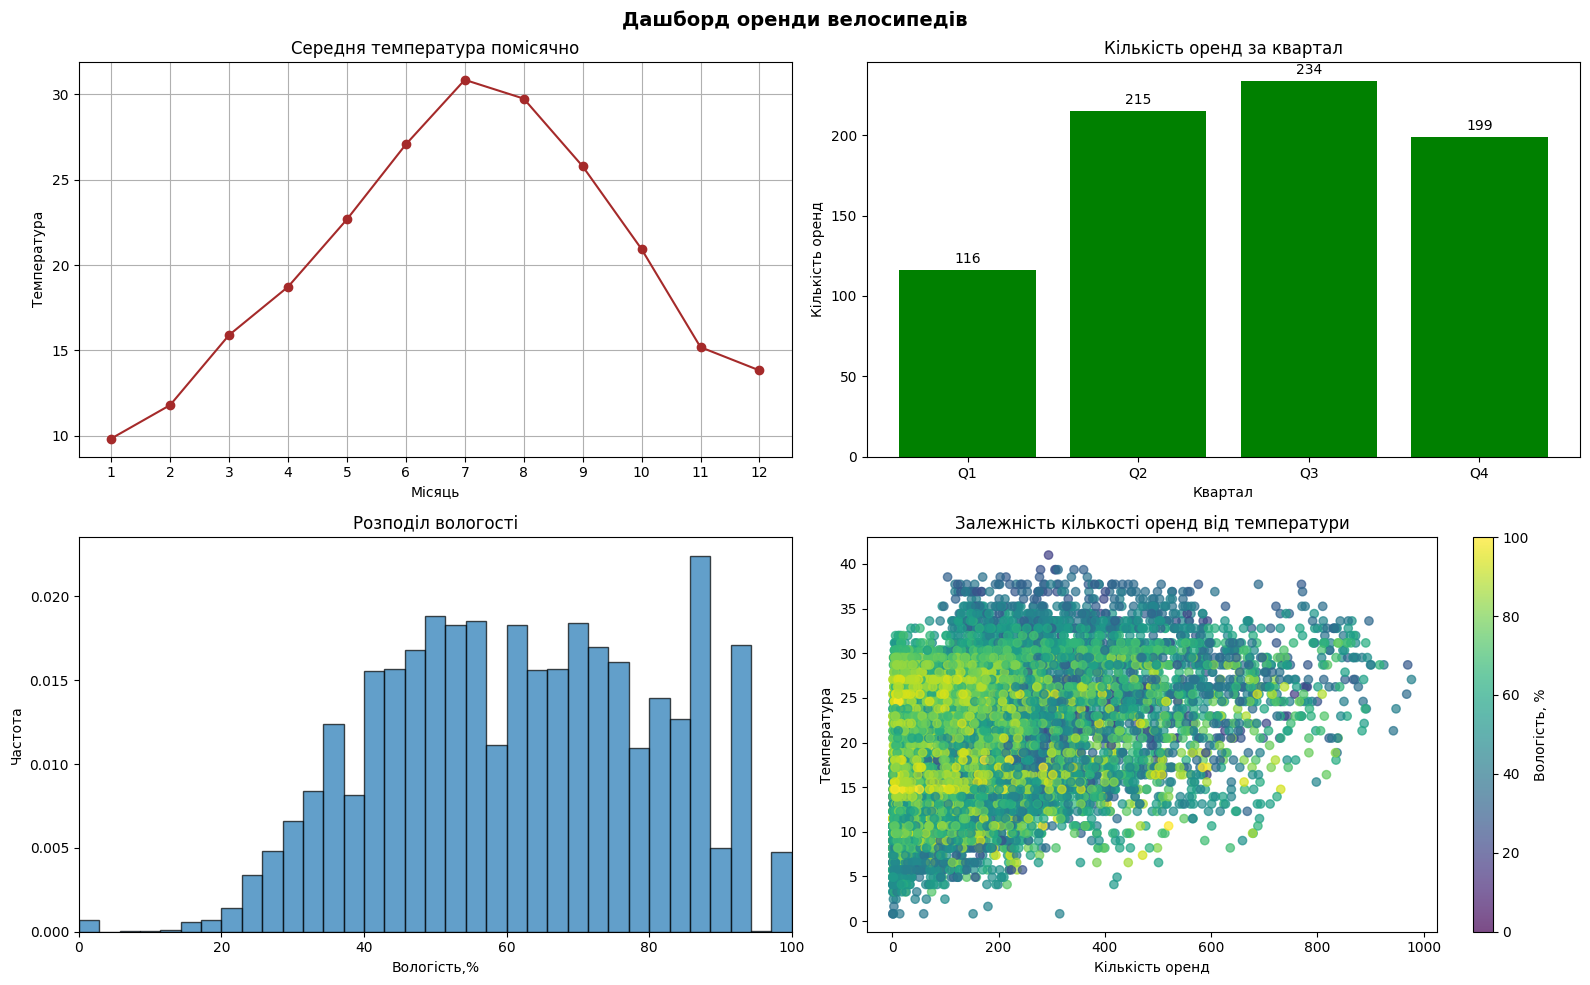

In [9]:
#plt.subplot(nrows, ncols, index)
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(avg_temp_month, 'o-', color='brown')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.xticks(range(1,13))
plt.grid(True)

plt.subplot(2, 2, 2)
labels = ['Q1', 'Q2', 'Q3', 'Q4']
bars = plt.bar(labels, avg_count_q.values, color="green")
plt.title('Кількість оренд за квартал')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)


plt.subplot(2, 2, 3)
plt.hist(df['humidity'], density= True, alpha=0.7, edgecolor='black', bins=35)
plt.title('Розподіл вологості')
plt.xlabel('Вологість,%')
plt.ylabel('Частота')
plt.xlim(0, 100) #щоб бін будувався від 0-100 без відступів

plt.subplot(2, 2, 4)
plt.scatter(df['count'], df['temp'], c=df['humidity'], cmap='viridis', alpha=0.7)
plt.title('Залежність кількості оренд від температури')
plt.xlabel('Кількість оренд')
plt.ylabel('Температура')
plt.colorbar(label='Вологість, %')


plt.suptitle('Дашборд оренди велосипедів', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

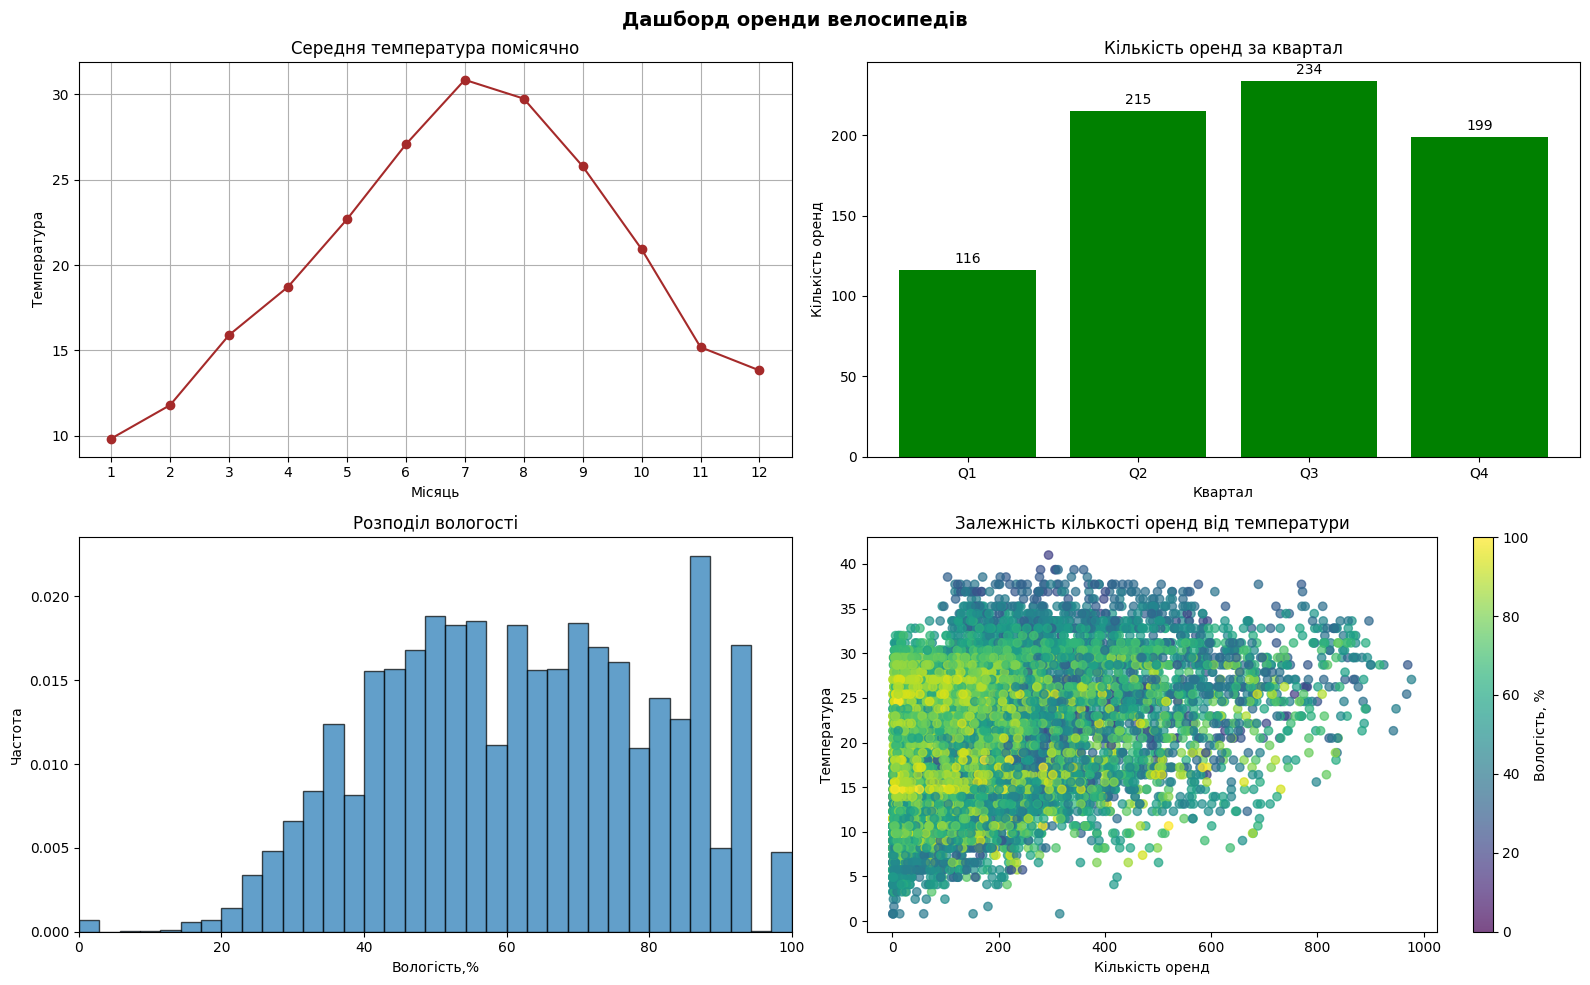

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(16,10))

ax[0, 0].plot(avg_temp_month, 'o-', color='brown')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].set_xticks(range(1,13))
ax[0, 0].grid (True)


labels = ['Q1', 'Q2', 'Q3', 'Q4']
bars = ax[0, 1].bar(labels, avg_count_q.values, color="green")
ax[0, 1].set_title('Кількість оренд за квартал')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Кількість оренд')
ax[0, 1].bar_label(bars, fmt="%.0f", padding=3, fontsize=10)


ax[1, 0].hist(df['humidity'], density= True, alpha=0.7, edgecolor='black', bins=35)
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість,%')
ax[1, 0].set_ylabel('Частота')
ax[1, 0].set_xlim(0, 100) #щоб бін будувався від о-100 без відступів


sc = ax[1, 1].scatter(df['count'], df['temp'], c=df['humidity'], cmap='viridis', alpha=0.7)
ax[1, 1].set_title('Залежність кількості оренд від температури')
ax[1, 1].set_xlabel('Кількість оренд')
ax[1, 1].set_ylabel('Температура')
fig.colorbar(sc, ax=ax[1, 1], label='Вологість, %')

fig.suptitle('Дашборд оренди велосипедів', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Відповідь:**
Коли ми будуємо графіки використовуючи plt.subplot(), ми створюєм фігуру і потім активуємо кожну панель(наприклад, `plt.subplot(2, 2, 1)`) і всі подальші налаштування автоматично малюються саме в ній.

Використовуючи plt.subplots() ми одразу створюєм всю сітку графіків одним рядком і отримуєм доступ до неї через змінну **ax**, де кожна панель - це **ax[0,0], ax[0,1]** і тд.

Зі свого досвіду скажу, що другий спосіб зручніший, коли графіків декілька — менше шансів помилитись, до якої панелі застосовується команда, і легше потім щось поправити чи скопіювати шматок коду для іншої панелі.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [76]:
import matplotlib.dates as mdates

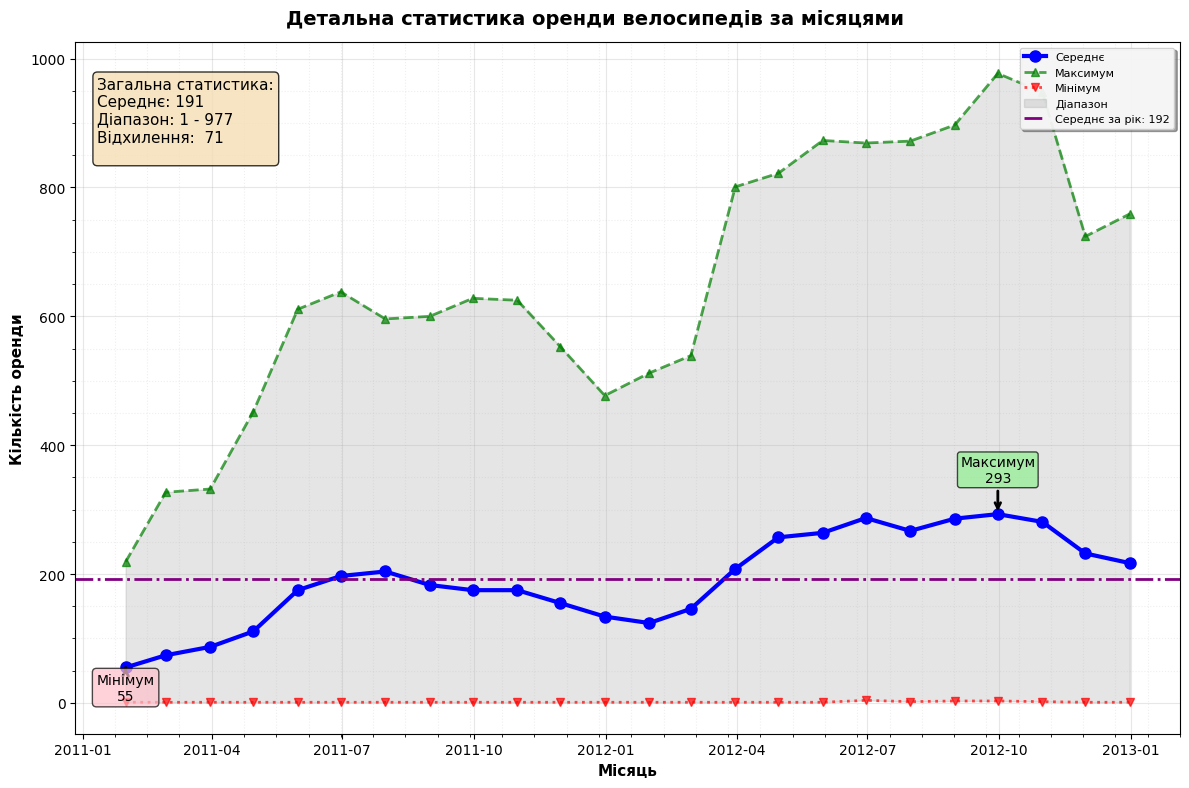

In [78]:
fig, ax = plt.subplots(figsize=(12, 8))

#Три лінії: середнє, максимум, мінімум за місяцями
#Різні стилі ліній: суцільна, пунктирна, крапкова + різні маркери
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

#Заливка області між мінімумом та максимумом
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
               alpha=0.2, color='gray', label='Діапазон')

#Дві анотації: для найвищого та найнижчого середнього значення
max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
    xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
    arrowprops=dict(arrowstyle='->', color='black', lw=2),
    fontsize=10, ha='center',
    bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgreen', alpha=0.7)
)

min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
    xy=(min_idx, min_val), xytext=(min_idx, min_val - 50),
    arrowprops=dict(arrowstyle='->', color='black', lw=2),
    fontsize=10, ha='center',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='pink', alpha=0.7)
)

#Горизонтальна лінія середнього за весь рік
overall_mean =  df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

#Двошарова сітка: основна та допоміжна
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

#Стилізована легенда з тінню
ax.legend(loc='upper right', fontsize=8, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

#Текстовий блок зі статистикою в кутку графіка
textstr = f'Загальна статистика:\n'
textstr += f'Середнє: {monthly_stats['mean'].mean():.0f}\n'
textstr += f'Діапазон: {monthly_stats['min'].min():.0f} - {monthly_stats['max'].max():.0f}\n'
textstr += f'Відхилення:  {monthly_stats['mean'].std():.0f}\n'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

#Професійне оформлення: заголовки, підписи осей з жирним шрифтом
fig.suptitle('Детальна статистика оренди велосипедів за місяцями', fontsize=14, fontweight='bold')
ax.set_xlabel('Місяць', fontsize=11, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=11, fontweight='bold')

plt.tight_layout()

plt.show()

**Відповідь:**
1.Додавання анотацій на графік дає можливість будь-кому, хто бачить графік вперше легко орієнтуватись в тому, що зображено на ньому.

2.fill_between() використовується для кольорового заповнення простору між двома кривими або лініями

3.Текстовий блок забезпечує швидкий доступ до зведеної статистики і перетворює графік на самодостатній бізнес-звіт.